In [2]:
import os
import re
import numpy as np
import tifffile
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
from natsort import natsorted
import pandas as pd
import glob

import matplotlib.patches as mpatches
import matplotlib.path as mpath 
from matplotlib.collections import PathCollection
import matplotlib.colors as mcolors

In [3]:
# Function to sort files naturally
def natural_sort_key(s):
    return [int(text) if text.isdigit() else text.lower() for text in re.split('([0-9]+)', s)]

# Function to calculate SSIM
def calculate_ssim(original_file, compressed_file):
    ssim_scores = []
    with tifffile.TiffFile(original_file) as tif_original:
        with tifffile.TiffFile(compressed_file) as tif_compressed:
            for original_frame, compressed_frame in zip(tif_original.series[0].pages, tif_compressed.series[0].pages):
                original_image = original_frame.asarray()
                compressed_image = compressed_frame.asarray()
                score = ssim(original_image, compressed_image, data_range=compressed_image.max() - compressed_image.min())
                ssim_scores.append(score)
    return np.median(ssim_scores) 

# New function to calculate SSIM
def calculate_ssim_folder(original_folder, compressed_folder):
    ssim_results = []
    original_files = natsorted([f for f in os.listdir(original_folder) if f.endswith('.tiff') and not f.startswith('.')])
    compressed_files = natsorted([f for f in os.listdir(compressed_folder) if f.endswith('.tiff') and not f.startswith('.')])
    
    for original_file, compressed_file in zip(original_files, compressed_files):
        ssim_scores = []
        try:
            with tifffile.TiffFile(os.path.join(original_folder, original_file)) as tif_original:
                with tifffile.TiffFile(os.path.join(compressed_folder, compressed_file)) as tif_compressed:
                    for original_frame, compressed_frame in zip(tif_original.series[0].pages, tif_compressed.series[0].pages):
                        original_image = original_frame.asarray()
                        compressed_image = compressed_frame.asarray()
                        score = ssim(original_image, compressed_image, data_range=compressed_image.max() - compressed_image.min())
                        ssim_scores.append(score)
            if ssim_scores:
                median_ssim = np.median(ssim_scores)
                ssim_results.append({'original_file': original_file, 'compressed_file': compressed_file, 'ssim': median_ssim})
        except Exception as e:
            print(f"Error processing files {original_file} and {compressed_file}: {e}")
    return ssim_results


# Function to get the total size of files in a folder
def get_total_size_of_files(folder_path, file_extensions):
    total_size = 0
    for file in os.listdir(folder_path):
        if any(file.endswith(ext) for ext in file_extensions):
            total_size += os.path.getsize(os.path.join(folder_path, file))
    return total_size

# Function to extract the k and lev values from the label
def extract_k_lev(label):
    """
    Extracts the k and lev values from the label.
    Assumes the label format is like 'sparz_k5_rt35_lev0'.
    """
    k_match = re.search(r'_k(\d+)_', label)
    lev_match = re.search(r'_lev(\d+)', label)
    k_value = int(k_match.group(1)) if k_match else None
    lev_value = int(lev_match.group(1)) if lev_match else None
    return k_value, lev_value

In [4]:
# Function to read .h5r files
from h5r_functions import h5r_to_df
from glob import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

In [13]:
# loop through all folders and extract the file paths
main_folder = "/Volumes/X10/2.Areas/HMS/SPARZ/figure_3_data/localizations/"
csv_files = glob(f"{main_folder}/median*/*.csv", recursive=True)

# extract the condition names
conditions = [os.path.basename(os.path.dirname(file)).split('_')[-1].replace('lev', 'level_') for file in csv_files]
conditions, csv_files



(['raw', 'sparz'],
 ['/Volumes/X10/2.Areas/HMS/SPARZ/figure_3_data/localizations/median_raw/20250306_Loc5_RAW.csv',
  '/Volumes/X10/2.Areas/HMS/SPARZ/figure_3_data/localizations/median_sparz/20250306_Loc5_SPARZmedian.csv'])

# Localization comparison - Jaccard

In [15]:
# Function for 3D Jaccard index of two point clouds
def pointcloud_to_voxels(data, voxel_size):
    """
    Convert point cloud data to a set of occupied voxels.
    
    Parameters:
    - data: DataFrame or numpy array containing x, y, z coordinates.
    - voxel_size: The size of the voxel used for binning the points.
    
    Returns:
    - A set of tuples representing the occupied voxel indices.
    """
    # Compute voxel indices for each point
    voxel_indices = (data / voxel_size).astype(int)
    
    # Convert to set for unique voxel indices
    occupied_voxels = set(map(tuple, voxel_indices.values))
    
    return occupied_voxels

def compute_jaccard_similarity_manual(u, v, voxel_size=0.5):
    """
    Compute the Jaccard Similarity between two sets of points using manual voxelization and alternative intersection computation.
    """
    
    # Convert dataframes to voxel sets
    set_u = pointcloud_to_voxels(u, voxel_size)
    set_v = pointcloud_to_voxels(v, voxel_size)
    
    # Compute intersection using an alternative method
    intersection_count = len(set_u.intersection(set_v))
    union_count = len(set_u.union(set_v))
    
    return intersection_count / union_count if union_count != 0 else 0.0

# nearest neighbors function
def compute_nearest_neighbours(df1, df2, n_neighbors=1, algorithm='ball_tree'):
    # Determine the number of rows in each dataframe
    len_df1 = len(df1)
    len_df2 = len(df2)

    print(f"Original lengths: df1={len_df1}, df2={len_df2}")

    # If the dataframes have different number of rows
    if len_df1 != len_df2:
        # Determine which dataframe is smaller
        if len_df1 < len_df2:
            # Pad df1 with dummy rows
            df1 = pd.concat([df1, pd.DataFrame(np.zeros((len_df2 - len_df1, df1.shape[1])), columns=df1.columns)], ignore_index=True)
        else:
            # Pad df2 with dummy rows
            df2 = pd.concat([df2, pd.DataFrame(np.zeros((len_df1 - len_df2, df2.shape[1])), columns=df2.columns)], ignore_index=True)

    print(f"Padded lengths: df1={len(df1)}, df2={len(df2)}")

    # Compute the nearest neighbors
    nbrs = NearestNeighbors(n_neighbors=n_neighbors, algorithm=algorithm).fit(df1)
    distances, indices = nbrs.kneighbors(df2)

    print(f"Distances and indices lengths: distances={len(distances)}, indices={len(indices)}")

    # If df1 was padded, remove the dummy rows from the indices
    if len_df1 < len_df2:
        indices = indices[:len_df1]
    # If df2 was padded, remove the dummy rows from the distances and indices
    elif len_df1 > len_df2:
        distances = distances[:len_df2]
        indices = indices[:len_df2]

    print(f"Final lengths: distances={len(distances)}, indices={len(indices)}")

    return distances, indices


In [56]:
raw_df = pd.read_csv(csv_files[0])
sparz_df = pd.read_csv(csv_files[1])
max_image_id_sparz = sparz_df['image-ID'].max()
raw_df = raw_df[raw_df['image-ID'] <= max_image_id_sparz]
raw_df.shape, sparz_df.shape

((217569, 33), (217540, 33))

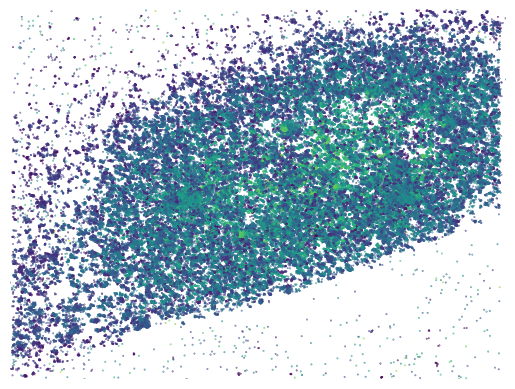

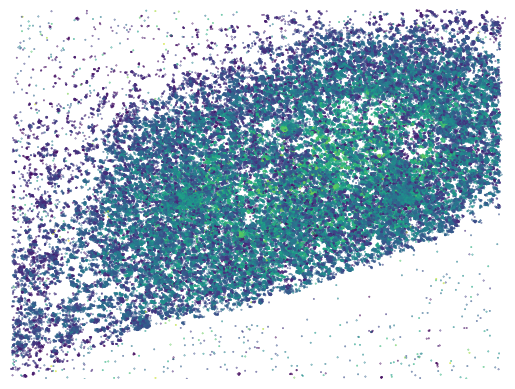

Original lengths: df1=217540, df2=217569
Padded lengths: df1=217569, df2=217569
Distances and indices lengths: distances=217569, indices=217569
Final lengths: distances=217569, indices=217540


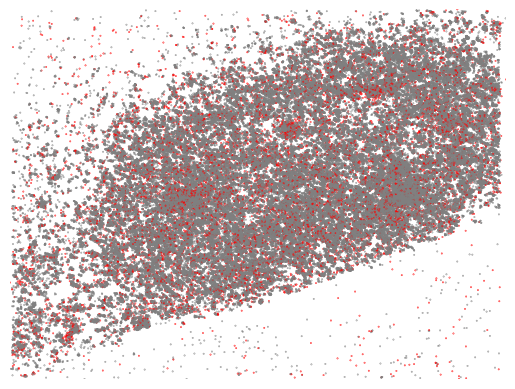

In [60]:
voxel_size = 40
s = 0.1
# x_lim = (13800, 15800)
# y_lim = (8500, 10500)

x_lim = (raw_df['x'].min(), raw_df['x'].max())
y_lim = (raw_df['y'].min(), raw_df['y'].max())



plt.scatter(x = raw_df.x, y = raw_df.y, c = raw_df.z, s = s)
plt.xlim(x_lim)
plt.ylim(y_lim)
plt.gca().set_frame_on(False)
plt.gca().get_xaxis().set_visible(False)
plt.gca().get_yaxis().set_visible(False)
plt.xticks([])
plt.yticks([])
plt.show()

jaccard_results = []

plt.scatter(x = sparz_df.x, y = sparz_df.y, c = sparz_df.z, s = s)
plt.xlim(x_lim)
plt.ylim(y_lim)
plt.gca().set_frame_on(False)
plt.gca().get_xaxis().set_visible(False)
plt.gca().get_yaxis().set_visible(False)
plt.xticks([])
plt.yticks([])
plt.show()

distances, indices = compute_nearest_neighbours(sparz_df[['x', 'y', 'z']], raw_df[['x', 'y', 'z']], n_neighbors=1)
jaccard_to_append = compute_jaccard_similarity_manual(sparz_df[['x', 'y', 'z']], raw_df[['x', 'y', 'z']], voxel_size=voxel_size)
jaccard_results.append({'file': 'median', 'jaccard': jaccard_to_append, 'distances': distances})

raw_df['distances'] = distances.flatten()
raw_df['colors'] = np.where(raw_df['distances'] < 40, 'grey', 'red')

# Plot the df with localizations < 40 in grey and localizations > 40 in red
plt.scatter(x=raw_df.x, y=raw_df.y, c=raw_df.colors, s=s)
plt.xlim(x_lim)
plt.ylim(y_lim)
plt.gca().set_frame_on(False)
plt.gca().get_xaxis().set_visible(False)
plt.gca().get_yaxis().set_visible(False)
plt.xticks([])
plt.yticks([])
plt.show()


In [61]:
jaccard_results

[{'file': 'median',
  'jaccard': 0.44559908054784025,
  'distances': array([[22.75490824],
         [29.18494232],
         [19.35004468],
         ...,
         [61.58540164],
         [30.05850078],
         [10.80030208]], shape=(217569, 1))}]

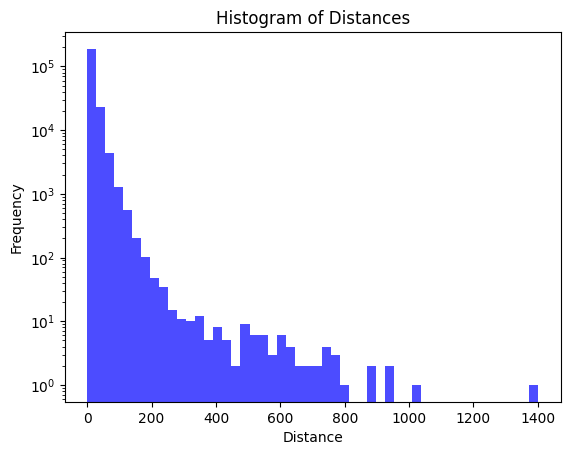

In [66]:
plt.hist(distances, bins=50, color='blue', alpha=0.7)
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.yscale('log')
plt.title('Histogram of Distances')
plt.show()

In [65]:
np.min(distances), np.max(distances)

(np.float64(0.0), np.float64(1400.7372560548238))

# Structure comparison